# Compare saved detector runs
Change `RUNS`, `SELECTION_MODE`, and `POLICY` in the next cell. Two aliases of the same run are included as a **pipeline smoke test**: their metrics should be identical. For real comparisons, point each alias at a different run's `threshold_comparison` directory. This notebook loads exported scores only; it does not retrain, resweep thresholds, or retune a model.

Selections and scores below come from the same validation recordings (`tuned_validation`), so these are descriptive comparisons, not independent test-set estimates. The loader rejects incompatible data, preprocessing, threshold grids, matching rules, or selection constraints.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if not (ROOT / 'tap_recognition').is_dir():
    ROOT = ROOT.parent
assert (ROOT / 'tap_recognition').is_dir(), 'Open from repository root or main_notebooks/'

RUNS = {
    'Baseline A': 'testing_checkpoints/20260925_112046/threshold_comparison',
    'Baseline B (same run)': 'testing_checkpoints/20260925_112046/threshold_comparison',
}
SELECTION_MODE = 'max_f1'
POLICY = 'lookahead_12f'
assert len(RUNS) >= 2, 'Provide at least two uniquely named runs.'

def read_export(directory, name):
    path = directory / f'{name}.csv'
    if not path.is_file():
        raise FileNotFoundError(f'{path}: rerun the export cell in baseline_evaluation.ipynb')
    return pd.read_csv(path)

sources, selections, summaries, type_tables, file_tables = [], [], [], [], []
for label, folder in RUNS.items():
    directory = ROOT / folder
    selected = read_export(directory, 'selected_thresholds')
    chosen = selected[(selected.selection_mode == SELECTION_MODE) & (selected.policy == POLICY)]
    if len(chosen) != 1:
        raise ValueError(f'{label}: expected exactly one selection for {SELECTION_MODE}/{POLICY}')
    choice = chosen.iloc[0]
    if not bool(choice.feasible):
        raise ValueError(f'{label}: requested selection is infeasible: {choice.infeasible_reason}')
    tables = [read_export(directory, name) for name in
              ('comparison_summary', 'type_metrics_all_modes', 'recording_metrics_all_modes')]
    matching = [table[(table.selection_mode == SELECTION_MODE) & (table.policy == POLICY)].copy()
                for table in tables]
    for table in matching:
        assert len(table), f'{label}: selected mode/policy missing in an exported table'
        assert np.allclose(table.left_threshold, choice.left_threshold)
        assert np.allclose(table.right_threshold, choice.right_threshold)
        assert table.checkpoint_sha256.nunique() == 1
        assert table.checkpoint_sha256.iloc[0] == choice.checkpoint_sha256
        table['model'] = label
    summary, by_type, by_file = matching
    assert set(summary.level) == {'window', 'frame', 'event'}
    assert set(summary.side) == {'all', 'left', 'right'}
    assert len(summary) == 9
    for kind in ('window', 'event'):
        overall = summary[(summary.level == kind) & (summary.side == 'all')].iloc[0]
        for count in ('tp', 'fp', 'fn'):
            assert by_file[f'{kind}_{count}'].sum() == by_type[f'{kind}_{count}'].sum() == overall[count]
    sources.append(dict(model=label, folder=str(directory), model_id=choice.model_id,
                        checkpoint_sha256=choice.checkpoint_sha256,
                        validation_sha256=choice.validation_sha256,
                        preprocessing_sha256=choice.preprocessing_sha256,
                        evaluation_design=choice.evaluation_design))
    selections.append(choice.to_dict() | {'model': label})
    summaries.append(summary)
    type_tables.append(by_type)
    file_tables.append(by_file)
comparison_sources = pd.DataFrame(sources)
operating_points = pd.DataFrame(selections)
scores = pd.concat(summaries, ignore_index=True)
type_scores = pd.concat(type_tables, ignore_index=True)
file_scores = pd.concat(file_tables, ignore_index=True)
must_agree = ['validation_sha256', 'preprocessing_sha256', 'selection_split',
              'evaluation_split', 'evaluation_design', 'threshold_grid', 'recall_target',
              'fp_per_min_limit', 'timely_budget_frames', 'early_allowance_frames',
              'max_late_frames', 'refractory_sec', 'frame_label_half_width']
for field in must_agree:
    assert scores[field].nunique(dropna=False) == 1, f'Runs differ in {field}; comparison is not like-for-like'
first_label = next(iter(RUNS))
expected_files = set(file_scores[file_scores.model == first_label].file)
expected_types = set(type_scores[type_scores.model == first_label].recording_type)
for label in RUNS:
    assert set(file_scores[file_scores.model == label].file) == expected_files, 'Recordings differ'
    assert set(type_scores[type_scores.model == label].recording_type) == expected_types, 'Types differ'
if comparison_sources.checkpoint_sha256.nunique() < len(RUNS):
    print('Demo: some aliases use identical weights. Replace RUNS paths to compare different models.')
comparison_sources

Demo: some aliases use identical weights. Replace RUNS paths to compare different models.


,model,folder,model_id,checkpoint_sha256,validation_sha256,preprocessing_sha256,evaluation_design
0,Baseline A,/home/aprohack/desktop/work/tap-project/projec...,20260925_112046,6ffe3a01ef60c8eacf7976e3bc89a2dc461b352de6a00f...,107753c258a8d9ddd35b9b071d5af206d4c036b61bb116...,a126dc5f3b6c1b4251b721fbe18fd6cc5df269147af81e...,tuned_validation
1,Baseline B (same run),/home/aprohack/desktop/work/tap-project/projec...,20260925_112046,6ffe3a01ef60c8eacf7976e3bc89a2dc461b352de6a00f...,107753c258a8d9ddd35b9b071d5af206d4c036b61bb116...,a126dc5f3b6c1b4251b721fbe18fd6cc5df269147af81e...,tuned_validation


In [2]:
operating_points[['model', 'selection_mode', 'policy', 'left_threshold', 'right_threshold',
                  'macro_f1', 'left_recall', 'right_recall', 'fp_per_min']]

,model,selection_mode,policy,left_threshold,right_threshold,macro_f1,left_recall,right_recall,fp_per_min
0,Baseline A,max_f1,lookahead_12f,0.66,0.74,0.936538,0.9,0.95,0.360355
1,Baseline B (same run),max_f1,lookahead_12f,0.66,0.74,0.936538,0.9,0.95,0.360355


## Window classification
All models use their **selected** left/right thresholds. Bar heights are per-window metrics, not event alarm quality. `class_accuracy` requires the correct side; binary accuracy treats either side as a detected event. PR-AUC is threshold-independent.

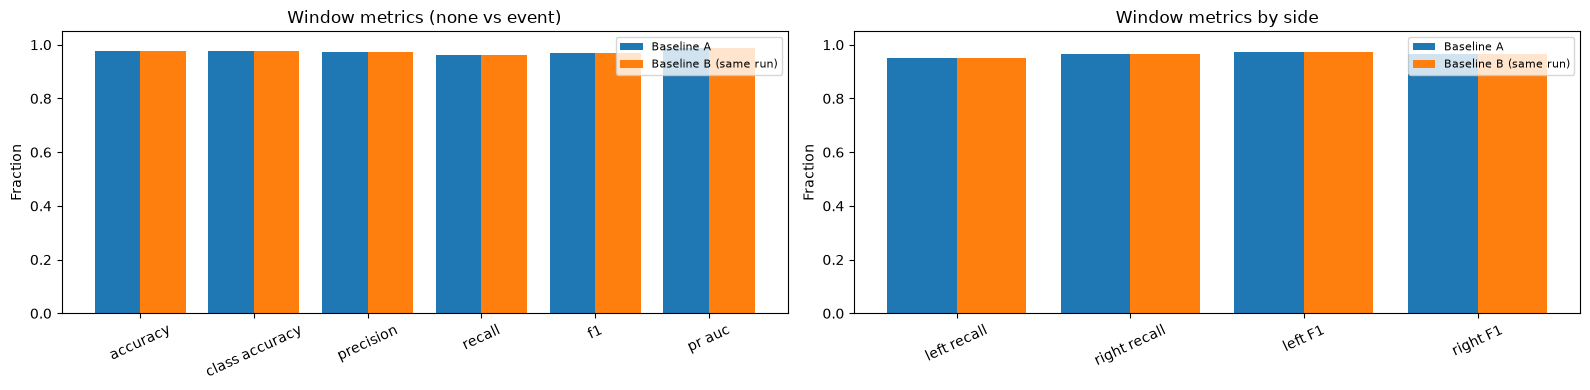

In [3]:
def grouped_bars(ax, table, columns, title, *, scale=1, ylabel='Score'):
    x = np.arange(len(columns))
    width = .8 / len(table)
    for i, (_, row) in enumerate(table.iterrows()):
        values = [row[column] * scale for column in columns]
        ax.bar(x - .4 + width*(i+.5), values, width, label=row['model'])
    ax.set(xticks=x, xticklabels=[name.replace('_', ' ') for name in columns],
           title=title, ylabel=ylabel)
    ax.tick_params(axis='x', rotation=25)
    ax.legend(fontsize=8)

window_metrics = scores[scores.level == 'window'].copy()
overall = window_metrics[window_metrics.side == 'all']
by_side = window_metrics[window_metrics.side != 'all'].copy()
by_side['side_recall'] = by_side.side + ' recall'
by_side['side_f1'] = by_side.side + ' F1'
per_side = pd.concat([
    by_side.pivot(index='model', columns='side_recall', values='recall'),
    by_side.pivot(index='model', columns='side_f1', values='f1')], axis=1).reindex(RUNS).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
grouped_bars(axes[0], overall, ['accuracy', 'class_accuracy', 'precision', 'recall', 'f1', 'pr_auc'],
             'Window metrics (none vs event)', ylabel='Fraction')
grouped_bars(axes[1], per_side, [c for c in per_side if c != 'model'],
             'Window metrics by side', ylabel='Fraction')
for ax in axes: ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [4]:
window_metrics[['model', 'side', 'left_threshold', 'right_threshold', 'n_samples',
                'tp', 'fp', 'fn', 'tn', 'accuracy', 'class_accuracy', 'precision',
                'recall', 'f1', 'pr_auc', 'roc_auc']]  # Full table: window_metrics.

,model,side,left_threshold,right_threshold,n_samples,tp,fp,fn,tn,accuracy,class_accuracy,precision,recall,f1,pr_auc,roc_auc
0,Baseline A,all,0.66,0.74,220.0,77.0,2.0,3.0,138.0,0.977273,0.977273,0.974684,0.962500,0.968553,0.986443,0.993036
1,Baseline A,left,0.66,0.74,220.0,19.0,0.0,1.0,200.0,0.995455,NaN,1.000000,0.950000,0.974359,1.000000,1.000000
2,Baseline A,right,0.66,0.74,220.0,58.0,2.0,2.0,158.0,0.981818,NaN,0.966667,0.966667,0.966667,0.988502,0.996354
9,Baseline B (same run),all,0.66,0.74,220.0,77.0,2.0,3.0,138.0,0.977273,0.977273,0.974684,0.962500,0.968553,0.986443,0.993036
10,Baseline B (same run),left,0.66,0.74,220.0,19.0,0.0,1.0,200.0,0.995455,NaN,1.000000,0.950000,0.974359,1.000000,1.000000
11,Baseline B (same run),right,0.66,0.74,220.0,58.0,2.0,2.0,158.0,0.981818,NaN,0.966667,0.966667,0.966667,0.988502,0.996354


## Frame diagnostics
These per-frame values depend on the selected thresholds, except PR-AUC/ROC-AUC. Frames near the same physical event are correlated; streaming event results below are the primary product metrics.

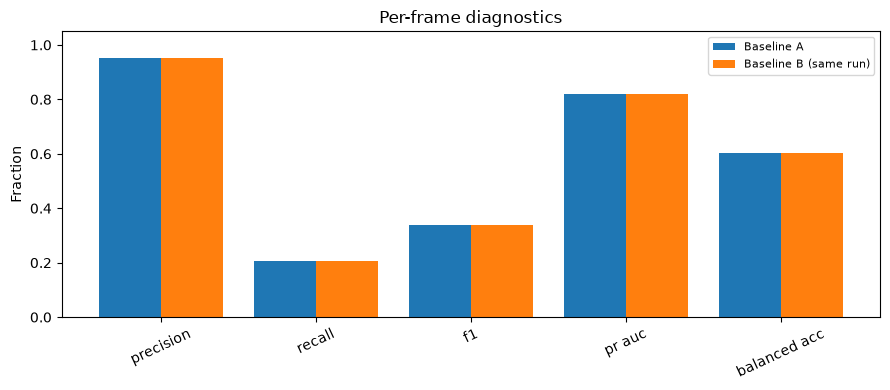

In [5]:
frame_metrics = scores[scores.level == 'frame'].copy()
fig, ax = plt.subplots(figsize=(9, 4))
grouped_bars(ax, frame_metrics[frame_metrics.side == 'all'],
             ['precision', 'recall', 'f1', 'pr_auc', 'balanced_acc'],
             'Per-frame diagnostics', ylabel='Fraction')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [6]:
frame_metrics[['model', 'side', 'precision', 'recall', 'f1', 'pr_auc', 'roc_auc',
               'n_samples', 'tp', 'fp', 'fn']]  # Full table: frame_metrics.

,model,side,precision,recall,f1,pr_auc,roc_auc,n_samples,tp,fp,fn
3,Baseline A,all,0.950685,0.206548,0.339364,0.821171,0.989712,66601.0,347.0,18.0,1333.0
4,Baseline A,left,0.932039,0.228571,0.367113,0.816413,0.998652,66601.0,96.0,7.0,324.0
5,Baseline A,right,0.958015,0.199206,0.329829,0.823813,0.988945,66601.0,251.0,11.0,1009.0
12,Baseline B (same run),all,0.950685,0.206548,0.339364,0.821171,0.989712,66601.0,347.0,18.0,1333.0
13,Baseline B (same run),left,0.932039,0.228571,0.367113,0.816413,0.998652,66601.0,96.0,7.0,324.0
14,Baseline B (same run),right,0.958015,0.199206,0.329829,0.823813,0.988945,66601.0,251.0,11.0,1009.0


## Streaming event detection
Event matching is class-aware, one-to-one, and uses the **actual alarm-emission frame**. FP/min counts unmatched alarms over all validation minutes, including early and wrong-side alarms. The selected operating point can differ per model even though its selection mode is the same.

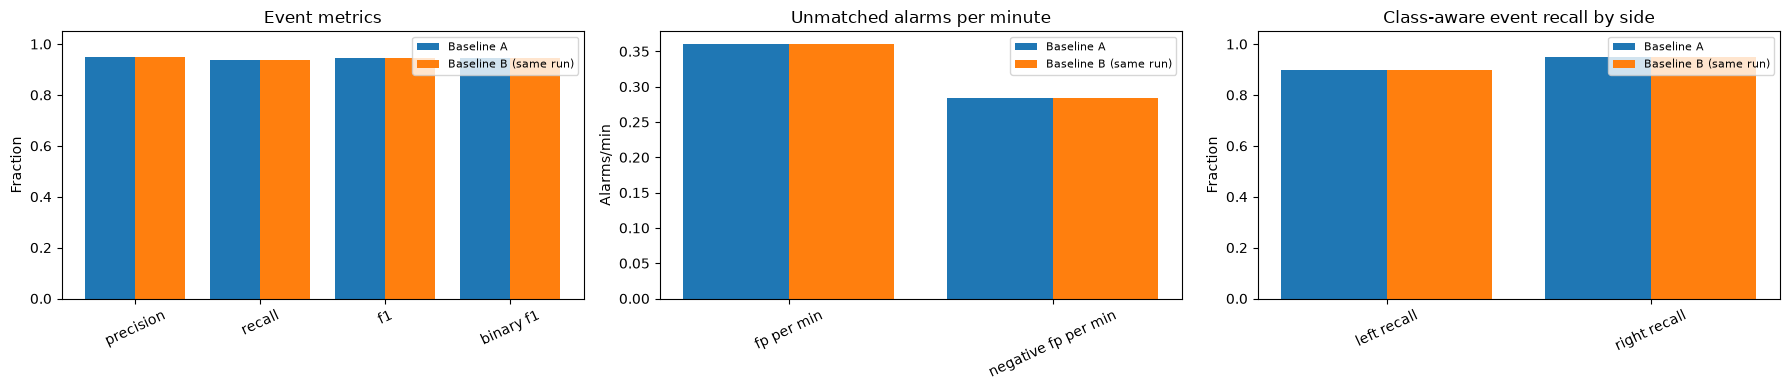

In [7]:
event_metrics = scores[scores.level == 'event'].copy()
event_overall = event_metrics[event_metrics.side == 'all']
event_side = event_metrics[event_metrics.side != 'all'].copy()
event_side['side_recall'] = event_side.side + ' recall'
side_recall = event_side.pivot(index='model', columns='side_recall', values='recall').reindex(RUNS).reset_index()
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
grouped_bars(axes[0], event_overall, ['precision', 'recall', 'f1', 'binary_f1'],
             'Event metrics', ylabel='Fraction')
grouped_bars(axes[1], event_overall, ['fp_per_min', 'negative_fp_per_min'],
             'Unmatched alarms per minute', ylabel='Alarms/min')
grouped_bars(axes[2], side_recall, [c for c in side_recall if c != 'model'],
             'Class-aware event recall by side', ylabel='Fraction')
axes[0].set_ylim(0, 1.05)
axes[2].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [8]:
event_metrics[['model', 'side', 'tp', 'fp', 'fn', 'precision', 'recall', 'f1',
               'binary_f1', 'fp_per_min', 'negative_fp_per_min',
               'left_threshold', 'right_threshold']]  # Full table: event_metrics.

,model,side,tp,fp,fn,precision,recall,f1,binary_f1,fp_per_min,negative_fp_per_min,left_threshold,right_threshold
6,Baseline A,all,75.0,4.0,5.0,0.949367,0.9375,0.943396,0.943396,0.360355,0.283279,0.66,0.74
7,Baseline A,left,18.0,1.0,2.0,0.947368,0.9000,0.923077,NaN,0.090089,0.000000,0.66,0.74
8,Baseline A,right,57.0,3.0,3.0,0.950000,0.9500,0.950000,NaN,0.270266,0.283279,0.66,0.74
15,Baseline B (same run),all,75.0,4.0,5.0,0.949367,0.9375,0.943396,0.943396,0.360355,0.283279,0.66,0.74
16,Baseline B (same run),left,18.0,1.0,2.0,0.947368,0.9000,0.923077,NaN,0.090089,0.000000,0.66,0.74
17,Baseline B (same run),right,57.0,3.0,3.0,0.950000,0.9500,0.950000,NaN,0.270266,0.283279,0.66,0.74


## Alarm latency
Deadline recall is the fraction of **all annotated events** detected before X frames (misses remain in the denominator). Mean/median/p90 latency includes matched events only and can be misleading if recall is low.

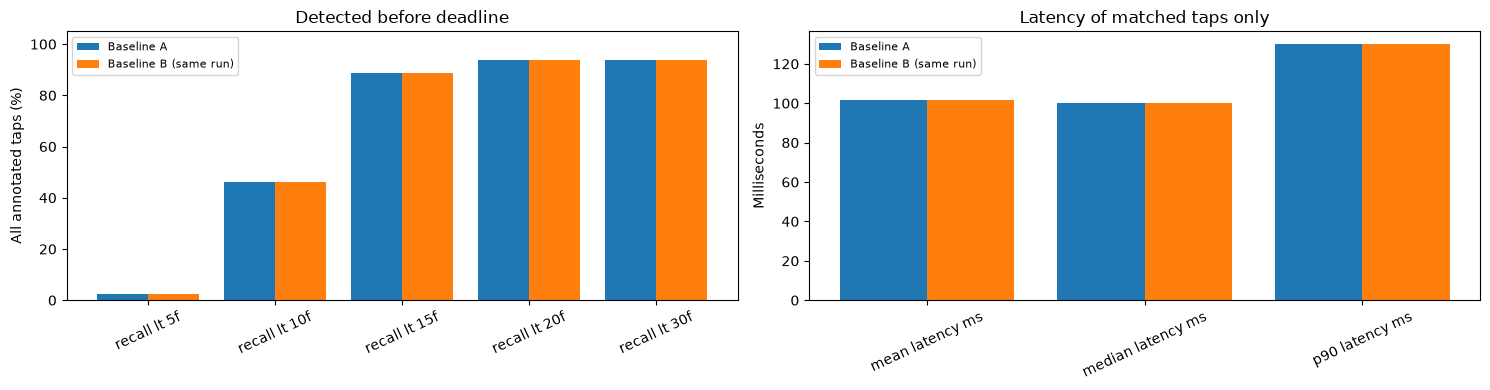

In [9]:
latency_metrics = event_overall[['model', 'left_threshold', 'right_threshold',
                                 'recall_lt_5f', 'recall_lt_10f', 'recall_lt_15f',
                                 'recall_lt_20f', 'recall_lt_30f', 'mean_latency_ms',
                                 'median_latency_ms', 'p90_latency_ms', 'tp', 'fn']].copy()
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
grouped_bars(axes[0], latency_metrics,
             ['recall_lt_5f', 'recall_lt_10f', 'recall_lt_15f', 'recall_lt_20f', 'recall_lt_30f'],
             'Detected before deadline', scale=100, ylabel='All annotated taps (%)')
grouped_bars(axes[1], latency_metrics,
             ['mean_latency_ms', 'median_latency_ms', 'p90_latency_ms'],
             'Latency of matched taps only', ylabel='Milliseconds')
axes[0].set_ylim(0, 105)
plt.tight_layout()
plt.show()

In [10]:
latency_metrics  # Filter model and compare recall/latency at the same deadline.

,model,left_threshold,right_threshold,recall_lt_5f,recall_lt_10f,recall_lt_15f,recall_lt_20f,recall_lt_30f,mean_latency_ms,median_latency_ms,p90_latency_ms,tp,fn
6,Baseline A,0.66,0.74,0.025,0.4625,0.8875,0.9375,0.9375,101.6,100.0,130.0,75.0,5.0
15,Baseline B (same run),0.66,0.74,0.025,0.4625,0.8875,0.9375,0.9375,101.6,100.0,130.0,75.0,5.0


## Recording types and individual files
Rows use the same selected policy and left/right thresholds as the event and window plots. Negative-only types have undefined event recall; their FP/min and false-positive window rates are the useful metrics. Grouped by type, every value is pooled over its files (not an average of file percentages). Some types contain only one file.

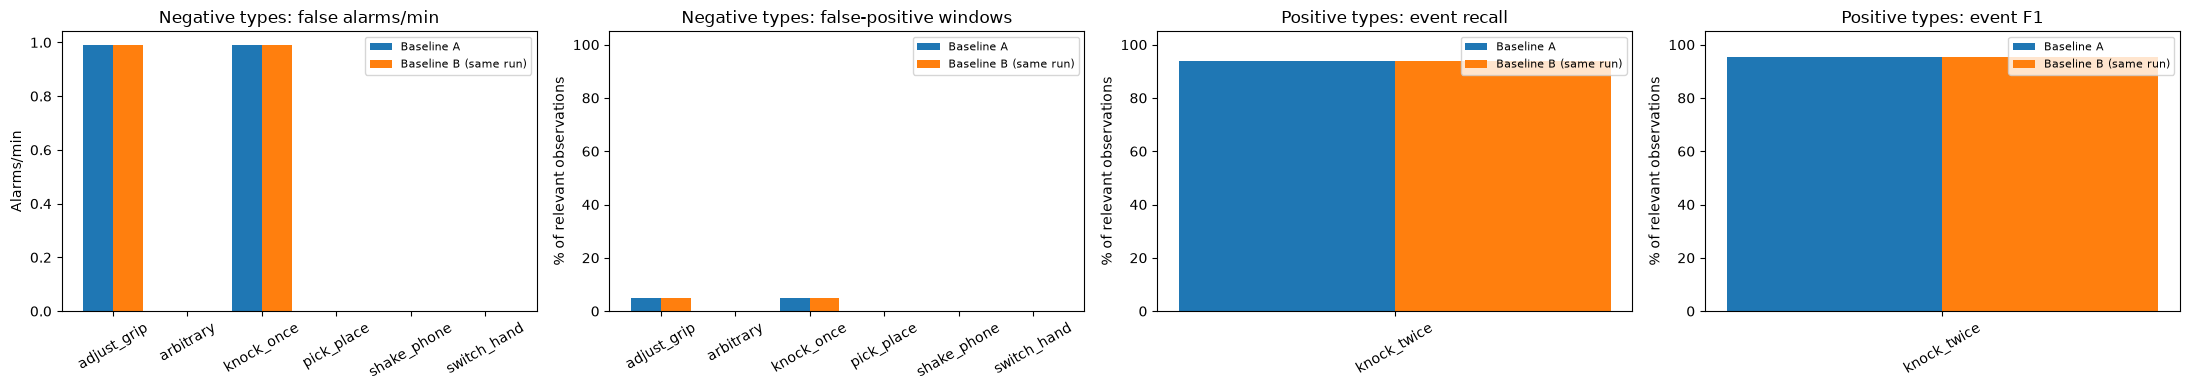

In [11]:
type_comparison = type_scores.copy()
negative = type_comparison[type_comparison.n_true_events == 0]
positive = type_comparison[type_comparison.n_true_events > 0]
fig, axes = plt.subplots(1, 4, figsize=(22, 4))
for ax, subset, metric, title, scale in [
        (axes[0], negative, 'event_fp_per_min', 'Negative types: false alarms/min', 1),
        (axes[1], negative, 'window_false_positive_rate', 'Negative types: false-positive windows', 100),
        (axes[2], positive, 'event_recall', 'Positive types: event recall', 100),
        (axes[3], positive, 'event_f1', 'Positive types: event F1', 100)]:
    x = sorted(subset.recording_type.unique())
    width = .8 / len(RUNS)
    for i, label in enumerate(RUNS):
        rows = subset[subset.model == label].set_index('recording_type').reindex(x)
        ax.bar(np.arange(len(x)) - .4 + width*(i+.5), rows[metric] * scale, width, label=label)
    ax.set(xticks=np.arange(len(x)), xticklabels=x, title=title)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
axes[0].set_ylabel('Alarms/min')
for ax in axes[1:]: ax.set(ylabel='% of relevant observations', ylim=(0, 105))
plt.tight_layout()
plt.show()

In [12]:
type_comparison[['model', 'recording_type', 'recordings', 'n_windows', 'n_true_events',
                 'event_tp', 'event_fp', 'event_fn', 'event_f1', 'event_fp_per_min',
                 'event_left_recall', 'event_right_recall', 'window_accuracy',
                 'window_false_positive_rate']]  # Full table: type_comparison.

,model,recording_type,recordings,n_windows,n_true_events,event_tp,event_fp,event_fn,event_f1,event_fp_per_min,event_left_recall,event_right_recall,window_accuracy,window_false_positive_rate
0,Baseline A,adjust_grip,1,20,0,0,1,0,0.000000,0.991572,NaN,NaN,0.9500,0.05
1,Baseline A,arbitrary,1,20,0,0,0,0,NaN,0.000000,NaN,NaN,1.0000,0.00
2,Baseline A,knock_once,1,20,0,0,1,0,0.000000,0.991080,NaN,NaN,0.9500,0.05
3,Baseline A,knock_twice,4,80,80,75,2,5,0.955414,0.495050,0.9,0.95,0.9625,NaN
4,Baseline A,pick_place,1,20,0,0,0,0,NaN,0.000000,NaN,NaN,1.0000,0.00
5,Baseline A,shake_phone,2,40,0,0,0,0,NaN,0.000000,NaN,NaN,1.0000,0.00
6,Baseline A,switch_hand,1,20,0,0,0,0,NaN,0.000000,NaN,NaN,1.0000,0.00
7,Baseline B (same run),adjust_grip,1,20,0,0,1,0,0.000000,0.991572,NaN,NaN,0.9500,0.05
8,Baseline B (same run),arbitrary,1,20,0,0,0,0,NaN,0.000000,NaN,NaN,1.0000,0.00
9,Baseline B (same run),knock_once,1,20,0,0,1,0,0.000000,0.991080,NaN,NaN,0.9500,0.05


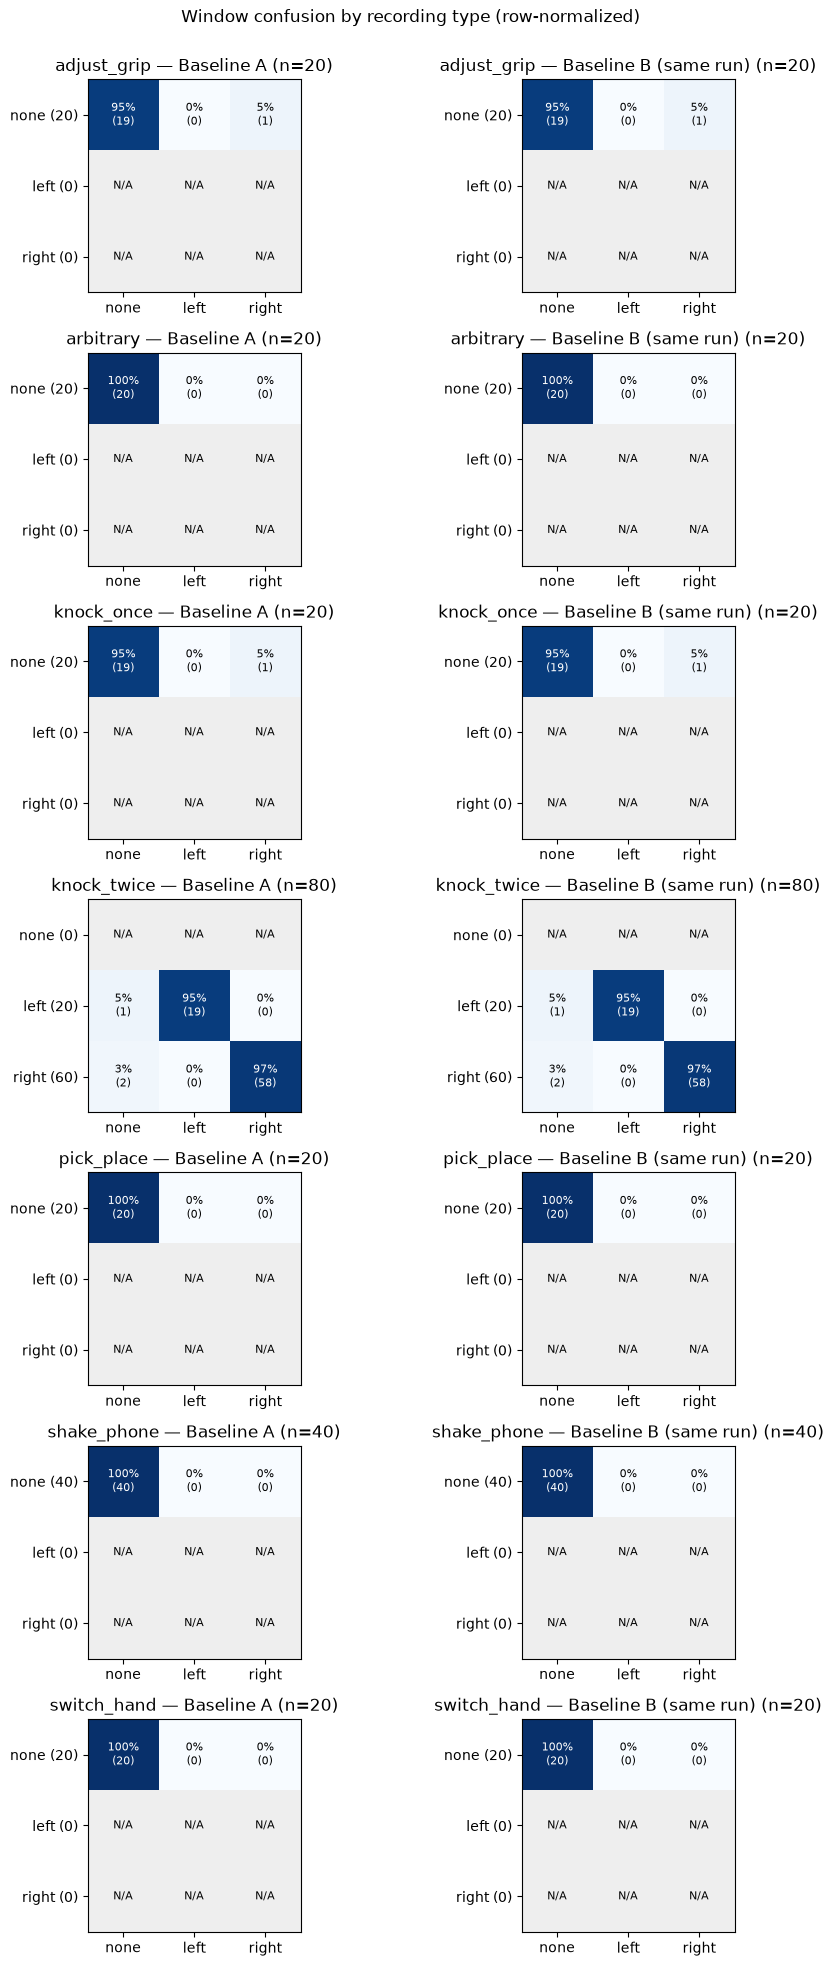

In [13]:
from matplotlib.colors import Normalize
confusion_rows = []
recording_types = sorted(expected_types)
fig, axes = plt.subplots(len(recording_types), len(RUNS),
                         figsize=(4.8*len(RUNS), 2.8*len(recording_types)), squeeze=False)
colors = plt.get_cmap('Blues').copy()
colors.set_bad('#eeeeee')
for i, recording_type in enumerate(recording_types):
    for j, model_name in enumerate(RUNS):
        row = type_comparison[(type_comparison.recording_type == recording_type) &
                              (type_comparison.model == model_name)].iloc[0]
        cm = np.array([[int(row[f'cm_{t}{p}']) for p in range(3)] for t in range(3)])
        totals = cm.sum(axis=1)
        fractions = np.divide(cm, totals[:, None], out=np.full((3, 3), np.nan),
                              where=totals[:, None] > 0)
        ax = axes[i, j]
        ax.imshow(np.ma.masked_invalid(fractions), cmap=colors, norm=Normalize(0, 1))
        ax.set(title=f'{recording_type} — {model_name} (n={cm.sum()})',
               xticks=range(3), xticklabels=('none', 'left', 'right'),
               yticks=range(3), yticklabels=[f'{name} ({n})' for name, n in
                                        zip(('none', 'left', 'right'), totals)])
        for t, true_class in enumerate(('none', 'left', 'right')):
            for p, predicted_class in enumerate(('none', 'left', 'right')):
                ax.text(p, t, f'{fractions[t, p]:.0%}\n({cm[t, p]})' if totals[t] else 'N/A',
                        ha='center', va='center', fontsize=8,
                        color='white' if totals[t] and fractions[t, p] > .55 else 'black')
                confusion_rows.append(dict(model=model_name, recording_type=recording_type,
                                           true_class=true_class, predicted_class=predicted_class,
                                           count=int(cm[t, p]), true_count=int(totals[t]),
                                           row_fraction=fractions[t, p]))
fig.suptitle('Window confusion by recording type (row-normalized)', y=1.001)
plt.tight_layout()
plt.show()
type_confusion_comparison = pd.DataFrame(confusion_rows)

In [14]:
type_confusion_comparison  # N/A rows have no observed examples of that true class.

,model,recording_type,true_class,predicted_class,count,true_count,row_fraction
0,Baseline A,adjust_grip,none,none,19,20,0.95
1,Baseline A,adjust_grip,none,left,0,20,0.00
2,Baseline A,adjust_grip,none,right,1,20,0.05
3,Baseline A,adjust_grip,left,none,0,0,NaN
4,Baseline A,adjust_grip,left,left,0,0,NaN
...,...,...,...,...,...,...,...
121,Baseline B (same run),switch_hand,left,left,0,0,NaN
122,Baseline B (same run),switch_hand,left,right,0,0,NaN
123,Baseline B (same run),switch_hand,right,none,0,0,NaN
124,Baseline B (same run),switch_hand,right,left,0,0,NaN


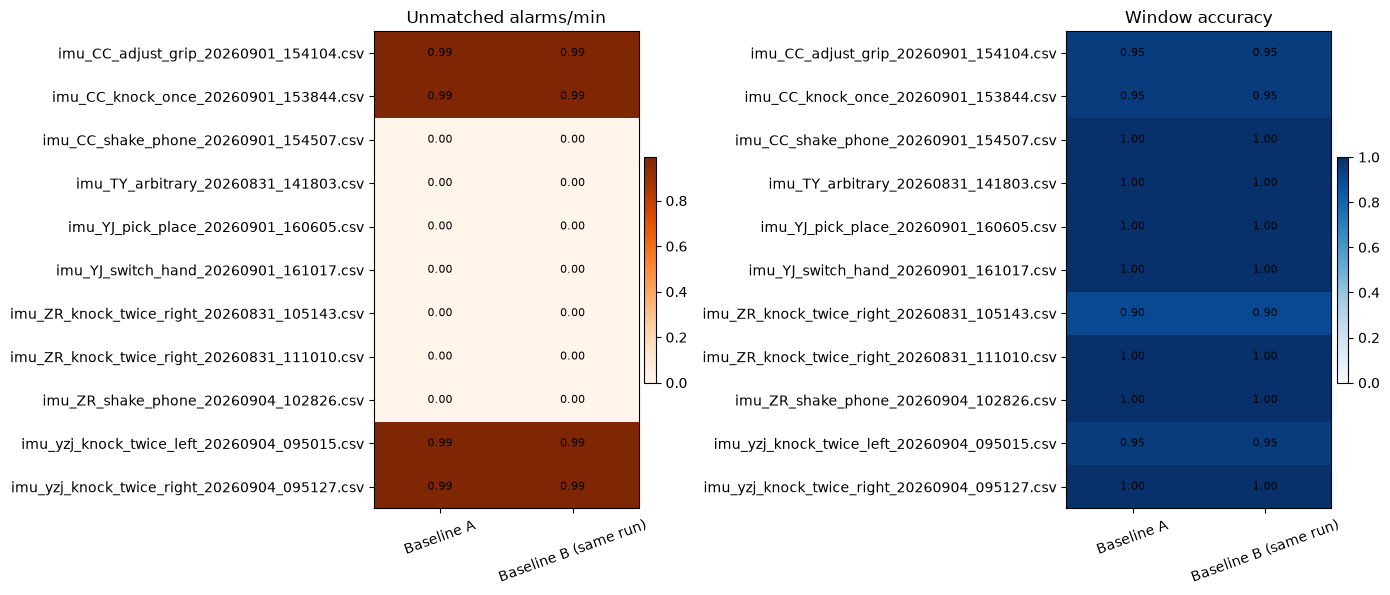

In [15]:
recording_comparison = file_scores.copy()
files = sorted(recording_comparison.file.unique())
fig, axes = plt.subplots(1, 2, figsize=(14, max(6, .55*len(files))))
for ax, field, label, cmap in [
        (axes[0], 'event_fp_per_min', 'Unmatched alarms/min', 'Oranges'),
        (axes[1], 'window_accuracy', 'Window accuracy', 'Blues')]:
    table = recording_comparison.pivot(index='file', columns='model', values=field).reindex(
        index=files, columns=list(RUNS))
    data = table.to_numpy(dtype=float)
    im = ax.imshow(data, aspect='auto', cmap=cmap, vmin=0, vmax=1 if field == 'window_accuracy' else None)
    ax.set(yticks=np.arange(len(files)), yticklabels=files, xticks=np.arange(len(RUNS)),
           xticklabels=list(RUNS), title=label)
    ax.tick_params(axis='x', rotation=20)
    for i in range(len(files)):
        for j in range(len(RUNS)):
            ax.text(j, i, f'{data[i, j]:.2f}',
                    ha='center', va='center', color='black', fontsize=8)
    fig.colorbar(im, ax=ax, fraction=.04, pad=.02)
plt.tight_layout()
plt.show()

In [16]:
recording_comparison[['model', 'file', 'recording_type', 'n_windows',
                      'n_true_events', 'event_tp', 'event_fp', 'event_fn',
                      'window_fp', 'window_fn', 'event_fp_per_min', 'minutes']]  # Full table: recording_comparison.

,model,file,recording_type,n_windows,n_true_events,event_tp,event_fp,event_fn,window_fp,window_fn,event_fp_per_min,minutes
0,Baseline A,imu_CC_adjust_grip_20260901_154104.csv,adjust_grip,20,0,0,1,0,1,0,0.991572,1.008500
1,Baseline A,imu_CC_knock_once_20260901_153844.csv,knock_once,20,0,0,1,0,1,0,0.991080,1.009000
2,Baseline A,imu_CC_shake_phone_20260901_154507.csv,shake_phone,20,0,0,0,0,0,0,0.000000,1.008333
3,Baseline A,imu_TY_arbitrary_20260831_141803.csv,arbitrary,20,0,0,0,0,0,0,0.000000,1.008833
4,Baseline A,imu_YJ_pick_place_20260901_160605.csv,pick_place,20,0,0,0,0,0,0,0.000000,1.008167
5,Baseline A,imu_YJ_switch_hand_20260901_161017.csv,switch_hand,20,0,0,0,0,0,0,0.000000,1.008500
6,Baseline A,imu_ZR_knock_twice_right_20260831_105143.csv,knock_twice,20,20,18,0,2,0,2,0.000000,1.014000
7,Baseline A,imu_ZR_knock_twice_right_20260831_111010.csv,knock_twice,20,20,20,0,0,0,0,0.000000,1.007833
8,Baseline A,imu_ZR_shake_phone_20260904_102826.csv,shake_phone,20,0,0,0,0,0,0,0.000000,1.008833
9,Baseline A,imu_yzj_knock_twice_left_20260904_095015.csv,knock_twice,20,20,18,1,2,0,1,0.991080,1.009000
